Importing Face Mask Dataset

In [6]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:11<00:00, 15.0MB/s]



In [7]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [8]:
!ls

data  face-mask-dataset.zip  sample_data


**Importing the Dependencies**

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [10]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2442.jpg', 'with_mask_205.jpg', 'with_mask_2201.jpg', 'with_mask_636.jpg', 'with_mask_1904.jpg']
['with_mask_1748.jpg', 'with_mask_2500.jpg', 'with_mask_3195.jpg', 'with_mask_1317.jpg', 'with_mask_1242.jpg']


In [11]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2852.jpg', 'without_mask_1877.jpg', 'without_mask_2708.jpg', 'without_mask_3085.jpg', 'without_mask_1468.jpg']
['without_mask_2711.jpg', 'without_mask_1616.jpg', 'without_mask_273.jpg', 'without_mask_1609.jpg', 'without_mask_2372.jpg']


In [12]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [13]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [14]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [15]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [16]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

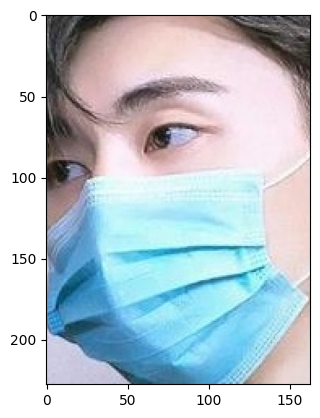

In [17]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

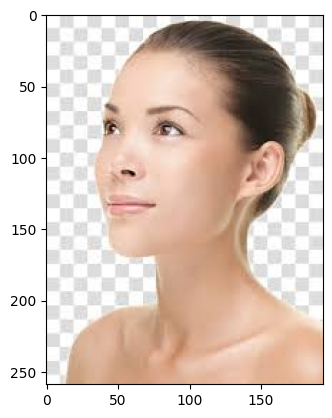

In [18]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [19]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [20]:
type(data)

list

In [21]:
len(data)

7553

array([[[110,  81,  73],
        [104,  77,  68],
        [ 94,  66,  58],
        ...,
        [133, 115, 101],
        [118, 100,  86],
        [100,  82,  68]],

       [[104,  76,  68],
        [116,  89,  80],
        [ 99,  71,  63],
        ...,
        [163, 145, 131],
        [147, 129, 115],
        [128, 110,  96]],

       [[112,  85,  76],
        [110,  82,  73],
        [107,  81,  72],
        ...,
        [178, 160, 146],
        [175, 157, 143],
        [168, 150, 136]],

       ...,

       [[124, 126, 125],
        [122, 124, 123],
        [122, 124, 123],
        ...,
        [205, 217, 231],
        [205, 217, 231],
        [204, 216, 229]],

       [[124, 126, 125],
        [121, 123, 122],
        [121, 123, 122],
        ...,
        [205, 217, 231],
        [204, 216, 230],
        [204, 216, 229]],

       [[123, 125, 124],
        [119, 121, 120],
        [120, 122, 121],
        ...,
        [204, 216, 230],
        [204, 216, 230],
        [204, 216, 229]]], dtype=uint8)
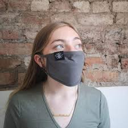

In [22]:
data[0]

In [23]:
type(data[0])

numpy.ndarray

In [24]:
data[0].shape

(128, 128, 3)

In [25]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [26]:
type(X)

numpy.ndarray

In [27]:
type(Y)

numpy.ndarray

In [28]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [29]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [31]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [32]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[77, 62, 65],
        [76, 61, 64],
        [80, 65, 69],
        ...,
        [91, 73, 78],
        [93, 73, 79],
        [88, 69, 75]],

       [[72, 57, 60],
        [76, 61, 63],
        [75, 61, 65],
        ...,
        [87, 70, 76],
        [87, 68, 74],
        [83, 65, 71]],

       [[73, 58, 61],
        [74, 60, 63],
        [69, 57, 61],
        ...,
        [85, 68, 76],
        [83, 66, 73],
        [81, 64, 70]],

       ...,

       [[82, 72, 67],
        [88, 78, 71],
        [92, 82, 76],
        ...,
        [19, 17, 18],
        [20, 18, 19],
        [21, 19, 20]],

       [[80, 71, 64],
        [85, 77, 70],
        [91, 81, 74],
        ...,
        [21, 19, 20],
        [21, 19, 20],
        [23, 21, 22]],

       [[77, 70, 60],
        [83, 77, 67],
        [90, 81, 72],
        ...,
        [21, 19, 20],
        [21, 19, 20],
        [23, 21, 22]]], dtype=uint8)
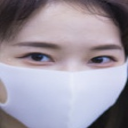

In [33]:
X_train[0]

In [34]:
X_train_scaled[0]

array([[[0.30196078, 0.24313725, 0.25490196],
        [0.29803922, 0.23921569, 0.25098039],
        [0.31372549, 0.25490196, 0.27058824],
        ...,
        [0.35686275, 0.28627451, 0.30588235],
        [0.36470588, 0.28627451, 0.30980392],
        [0.34509804, 0.27058824, 0.29411765]],

       [[0.28235294, 0.22352941, 0.23529412],
        [0.29803922, 0.23921569, 0.24705882],
        [0.29411765, 0.23921569, 0.25490196],
        ...,
        [0.34117647, 0.2745098 , 0.29803922],
        [0.34117647, 0.26666667, 0.29019608],
        [0.3254902 , 0.25490196, 0.27843137]],

       [[0.28627451, 0.22745098, 0.23921569],
        [0.29019608, 0.23529412, 0.24705882],
        [0.27058824, 0.22352941, 0.23921569],
        ...,
        [0.33333333, 0.26666667, 0.29803922],
        [0.3254902 , 0.25882353, 0.28627451],
        [0.31764706, 0.25098039, 0.2745098 ]],

       ...,

       [[0.32156863, 0.28235294, 0.2627451 ],
        [0.34509804, 0.30588235, 0.27843137],
        [0.36078431, 0

**Building a Convolutional Neural Networks (CNN)**

In [35]:
import tensorflow as tf
from tensorflow import keras

In [36]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [38]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - acc: 0.7567 - loss: 0.5268 - val_acc: 0.8942 - val_loss: 0.2602
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8793 - loss: 0.3086 - val_acc: 0.9041 - val_loss: 0.2485
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9049 - loss: 0.2461 - val_acc: 0.9140 - val_loss: 0.2335
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9148 - loss: 0.2222 - val_acc: 0.9306 - val_loss: 0.1892
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9297 - loss: 0.1833 - val_acc: 0.9455 - val_loss: 0.1534


**Model Evaluation**

In [39]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9292 - loss: 0.1998
Test Accuracy = 0.9291859865188599


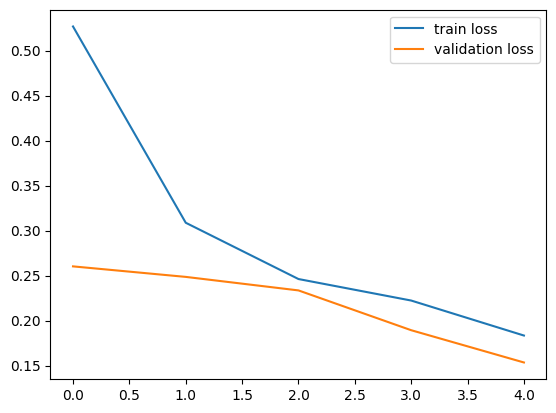

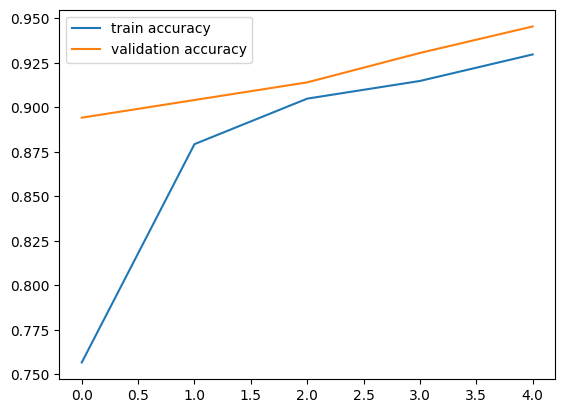

In [40]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/images_mask.jpeg


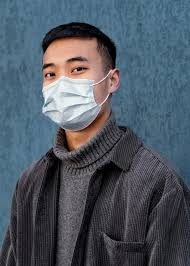

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
[[0.47719833 0.5833296 ]]
1
The person in the image is wearing a mask


In [41]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/image_without_mask.jpg


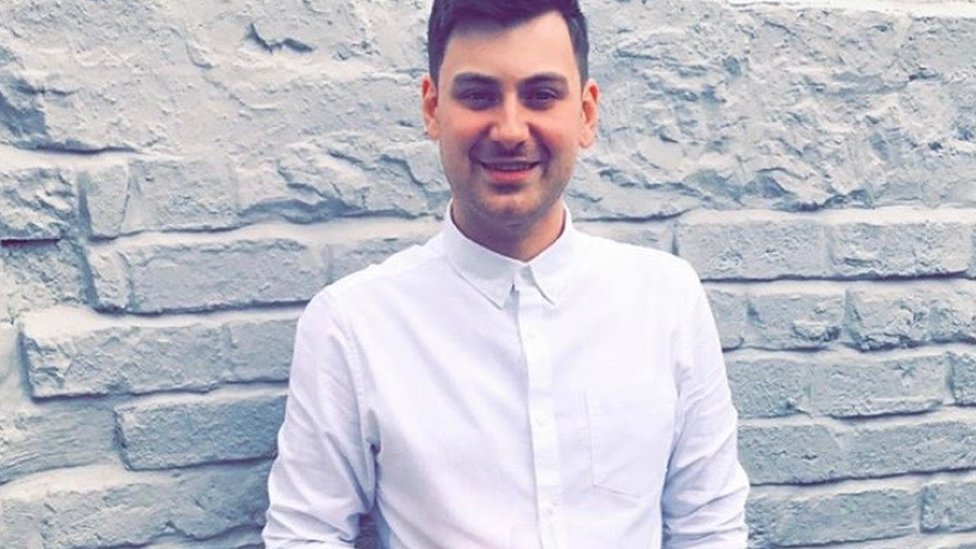

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction Probabilities: [[0.6027355  0.47897974]]
Predicted Label Index: 0
The person in the image is not wearing a mask


In [44]:


# Take image path
input_image_path = input("Path of the image to be predicted: ")

# Read image
input_image = cv2.imread(input_image_path)

# Check if image loaded correctly
if input_image is None:
    print("Image not found. Please check the file path.")
else:
    # Show image
    cv2_imshow(input_image)

    # Resize image
    input_image_resized = cv2.resize(input_image, (128, 128))

    # Normalize
    input_image_scaled = input_image_resized / 255.0

    # Reshape for model prediction
    input_image_reshaped = np.reshape(
        input_image_scaled,
        (1, 128, 128, 3)
    )

    # Predict
    input_prediction = model.predict(input_image_reshaped)

    print("Prediction Probabilities:", input_prediction)

    # Get predicted class
    input_pred_label = np.argmax(input_prediction)

    print("Predicted Label Index:", input_pred_label)

    # Final result
    if input_pred_label == 1:
        print("The person in the image is wearing a mask")
    else:
        print("The person in the image is not wearing a mask")

In [43]:
model.save("Mask_detector.h5")